In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('processed_smartphone_reviews.csv')
print(df.shape) # 데이터 잘 들어왔는지 확인

(50000, 29)


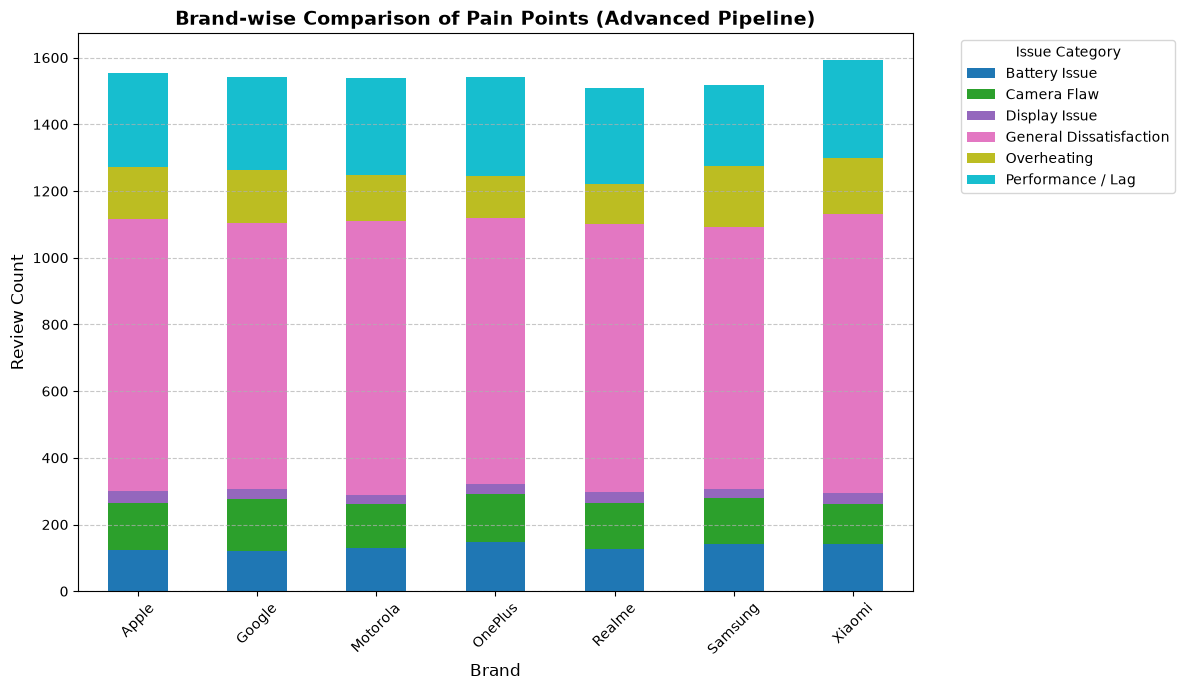

In [3]:
# 브랜드별 페인 포인트 교차 분석 데이터 추출
brand_pain_df = df[df['analysis_segment'] == 'Pain Point Group'].groupby(['brand', 'issue_category']).size().unstack(fill_value=0)

# 누적 막대그래프 시각화
ax = brand_pain_df.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')
plt.title('Brand-wise Comparison of Pain Points (Advanced Pipeline)', fontsize=14, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Issue Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# 브랜드별 페인 포인트 절대 빈도 집계 후, 행 기준 백분율(%)로 변환
brand_pain_count = df[df['analysis_segment'] == 'Pain Point Group'].groupby(['brand', 'issue_category']).size().unstack(fill_value=0)
brand_pain_ratio = brand_pain_count.div(brand_pain_count.sum(axis=1), axis=0) * 100

# 소수점 둘째 자리까지 반올림하여 깔끔하게 출력
print("=== 브랜드별 페인 포인트 점유율 비율 (%) ===")
display(brand_pain_ratio.round(2))

=== 브랜드별 페인 포인트 점유율 비율 (%) ===


issue_category,Battery Issue,Camera Flaw,Display Issue,General Dissatisfaction,Overheating,Performance / Lag
brand,,,,,,
Apple,7.98,9.14,2.32,52.32,10.10,18.15
Google,7.78,10.12,2.01,51.75,10.25,18.09
Motorola,8.39,8.65,1.76,53.32,8.97,18.92
OnePlus,9.60,9.40,1.88,51.69,8.24,19.20
Realme,8.35,9.28,2.05,53.35,7.89,19.09
Samsung,9.29,9.10,1.91,51.62,12.06,16.02
Xiaomi,8.91,7.59,2.01,52.51,10.41,18.57


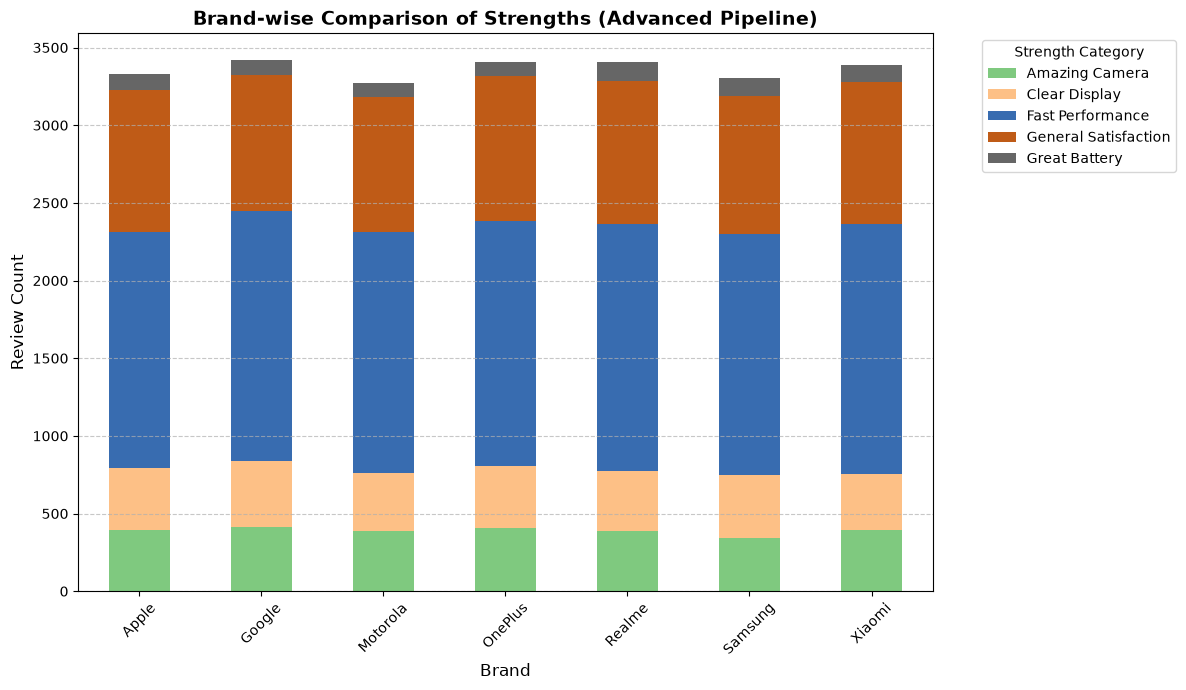

In [5]:
# 브랜드별 강점(Strength) 비교 집계
brand_strength = df[df['analysis_segment'] == 'Strength Group'].groupby(['brand', 'strength_category']).size().unstack(fill_value=0)

# 브랜드별 강점 누적 막대그래프 시각화
ax = brand_strength.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Accent')
plt.title('Brand-wise Comparison of Strengths (Advanced Pipeline)', fontsize=14, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Strength Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# 브랜드별 강점 절대 빈도 집계 후, 행 기준 백분율(%)로 변환
brand_strength_count = df[df['analysis_segment'] == 'Strength Group'].groupby(['brand', 'strength_category']).size().unstack(fill_value=0)
brand_strength_ratio = brand_strength_count.div(brand_strength_count.sum(axis=1), axis=0) * 100

# 소수점 둘째 자리까지 반올림하여 깔끔하게 출력
print("=== 브랜드별 강점 점유율 비율 (%) ===")
display(brand_strength_ratio.round(2))

=== 브랜드별 강점 점유율 비율 (%) ===


strength_category,Amazing Camera,Clear Display,Fast Performance,General Satisfaction,Great Battery
brand,,,,,
Apple,11.92,11.86,45.62,27.42,3.18
Google,12.13,12.42,46.96,25.69,2.81
Motorola,11.89,11.31,47.57,26.44,2.78
OnePlus,11.95,11.75,46.23,27.55,2.53
Realme,11.37,11.40,46.73,26.99,3.52
Samsung,10.30,12.33,47.03,26.89,3.45
Xiaomi,11.59,10.65,47.46,27.02,3.27


In [8]:
# 1. 브랜드별 전체 리뷰 개수 집계
total_by_brand = df['brand'].value_counts().rename('Total Reviews')

# 2. 브랜드별 'Pain Point Group'에 속하는 리뷰 개수 집계
pain_by_brand = df[df['analysis_segment'] == 'Pain Point Group']['brand'].value_counts().rename('Pain Point Reviews')

# 3. 두 데이터를 하나로 합치기
brand_pain_summary = pd.DataFrame({
    'Total Reviews': total_by_brand,
    'Pain Point Reviews': pain_by_brand
}).fillna(0)

# 4. 각 브랜드의 전체 리뷰 대비 페인 포인트 리뷰의 비율(%) 계산
brand_pain_summary['Pain Point Ratio (%)'] = (brand_pain_summary['Pain Point Reviews'] / brand_pain_summary['Total Reviews']) * 100
brand_pain_summary['Pain Point Ratio (%)'] = brand_pain_summary['Pain Point Ratio (%)'].round(2)

# 정수형 변환 및 출력
brand_pain_summary['Total Reviews'] = brand_pain_summary['Total Reviews'].astype(int)
brand_pain_summary['Pain Point Reviews'] = brand_pain_summary['Pain Point Reviews'].astype(int)

print("=== 브랜드별 전체 리뷰 대비 페인 포인트(불만) 비중 분석 표 ===")
display(brand_pain_summary)

=== 브랜드별 전체 리뷰 대비 페인 포인트(불만) 비중 분석 표 ===


,Total Reviews,Pain Point Reviews,Pain Point Ratio (%)
brand,,,
Apple,7144,1554,21.75
Google,7234,1542,21.32
Motorola,7061,1538,21.78
OnePlus,7136,1542,21.61
Realme,7132,1509,21.16
Samsung,7052,1517,21.51
Xiaomi,7241,1594,22.01
